In [61]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

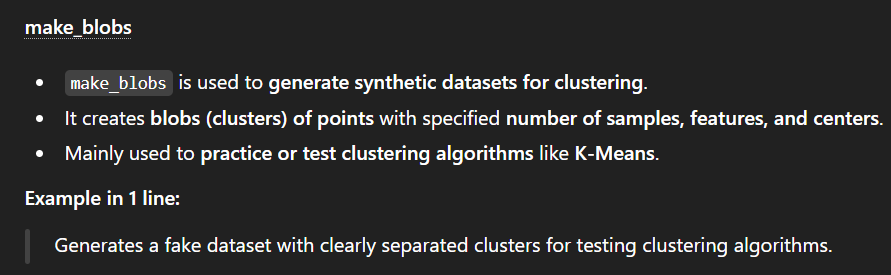

Synthetic dataset is the dataset which is not NATURAL and generated by laptop/computer

In [62]:
X,y = make_blobs(n_features=2,n_samples=1000,centers=3)

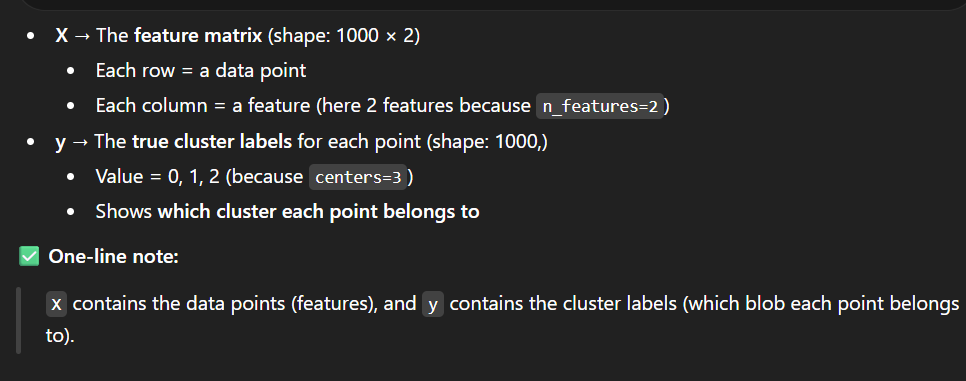

Blob == Cluster

In [63]:
X

array([[ 8.41665085, -4.22834817],
       [-2.6021134 ,  5.91439336],
       [ 2.91653502, -7.12310532],
       ...,
       [ 8.47468669, -6.1650195 ],
       [ 8.14925964, -3.91394286],
       [ 8.59392603, -5.10528604]])

In [64]:
X.shape

(1000, 2)

In [65]:
y

array([2, 1, 0, 0, 0, 2, 1, 0, 2, 0, 1, 0, 1, 2, 2, 0, 1, 2, 2, 2, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 2, 0, 0, 1, 2, 1, 1, 0, 1, 1, 1, 2, 1, 0, 2,
       0, 0, 1, 2, 1, 1, 0, 1, 0, 2, 0, 0, 2, 1, 1, 0, 1, 0, 1, 0, 1, 2,
       1, 2, 1, 2, 2, 2, 0, 1, 2, 1, 2, 2, 0, 1, 0, 2, 2, 2, 2, 1, 1, 0,
       2, 1, 2, 0, 2, 1, 0, 0, 0, 1, 0, 1, 1, 2, 1, 2, 0, 2, 2, 0, 1, 2,
       1, 0, 1, 0, 0, 2, 0, 2, 0, 0, 1, 1, 1, 2, 2, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 2, 2, 1, 1, 2, 1, 1, 2, 0, 1, 2,
       1, 0, 1, 0, 2, 1, 0, 1, 0, 0, 0, 2, 2, 1, 2, 2, 0, 0, 1, 0, 2, 2,
       2, 1, 1, 0, 2, 0, 1, 2, 1, 0, 1, 1, 1, 2, 1, 0, 2, 1, 1, 1, 0, 0,
       1, 0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 0, 2, 0, 0, 2, 2, 0, 1, 1, 1, 1,
       1, 2, 2, 0, 2, 0, 1, 1, 1, 2, 1, 0, 2, 2, 2, 1, 0, 0, 1, 2, 0, 1,
       1, 1, 2, 0, 0, 1, 2, 0, 1, 2, 1, 2, 1, 0, 1, 0, 2, 0, 1, 1, 1, 1,
       2, 0, 2, 1, 0, 2, 2, 2, 2, 2, 2, 0, 2, 1, 1, 0, 2, 0, 2, 0, 1, 2,
       1, 2, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,

Since; we wrote centers = 3 in make_blob method -: So; total 3 clusters each haiving a centroid/center at the mean value position of all the datapoints within that cluster will be formed

And whichever points belong to cluster-1 are labelled as 0
And whichever points belong to cluster-2 are labelled as 1
And whichever points belong to cluster-3 are labelled as 2 

in the y variable feature of dataset

In [66]:
len(y)

1000

In [67]:
y.shape

(1000,)

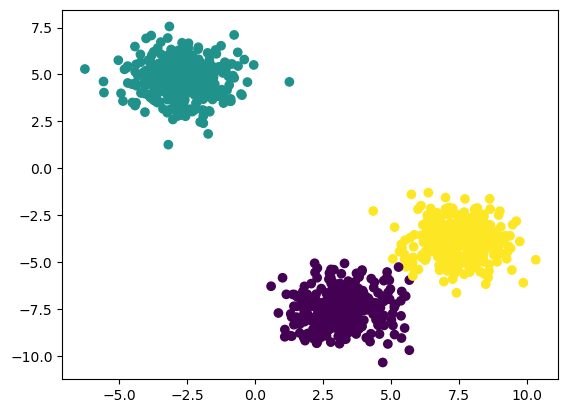

In [68]:
plt.scatter(x=X[:,0],y=X[:,1],c=y)

But; since this is an UNSUPERVISED M.L Algo -: So; we will never use "y" varaible feature which is a clustering label instead we will only use the "X" variable features representing the whole dataset and then on top of this X dataset we will apply K-means clustering algo.

Then; K-means clustering will cluster this dataset into a particular number of groups and then we will verify whether this K-means clustering will give the k=3 or not.

The same concept and process is valid and will be applied for Hierarichal & DB-Scan Clustering also.


In real-world scenario -: This will never happen where we will get a particular feature represting the cluster labels for the rows/records of a dataset. It would just give the "X" variable features of their dataset and algo will find "y" variable feature of cluster-labels on its own.

This "y" variable -: cluster labels for records is just for validation of clustering algo's returned by the make_blob technique/method.

But; In real world scenario u will never get a column/feature like "y" variable representing cluster labels for records/rows of dataset. Clustering algo's need to find cluster labels and clustering always on their own without any such column/feature like "y" variable representing cluster labels for validation purposes. 

Clustering will be done only by the Clustering algorithms as these are UNSUPERVISED M.L. algorithms. So; they would NOT have/given any Output/Labels.
So; they would just give only Clustering Labels for each record/row of the dataset in the same way given by "y" varaible column/feature of make_blob method

# So; using k-means we need to find k=3

In [69]:
# In k-means algo it is necessary to perform Standardization cause in this algo we will be using distance formula and calculate distance from all datapoints to each centroid.
# So; for this we need to do Standardization to bring everything in common scale/range.
# Standardization -- feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [70]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [71]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  We do not scale the output (target) variable because it is not used to measure distances between features, and we want the model’s predictions in the original units .i.e in original range of the target variable / O/P feature.

In [72]:
from sklearn.cluster import KMeans

In [73]:
# Elbow method-: to select k value
wcss=[] # wcss = within cluster sum of squares
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

wcss value will be stored in inertia_ attribute/property after training with instance of KMeans clustering-algo

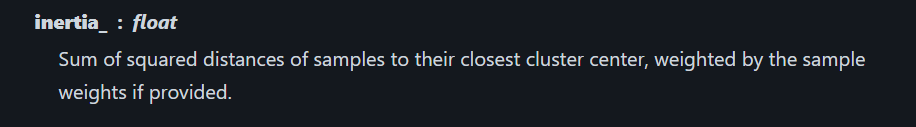

In [74]:
wcss
# As k value increase -: wcss value decreases which u can also see below in wcss array-:

[1340.0000000000005,
 221.28730926600167,
 57.0809414010877,
 49.05484595297624,
 45.78766034070366,
 37.548438288512074,
 32.28828312474768,
 28.48077130779489,
 27.02917566099134,
 23.796358724793702]

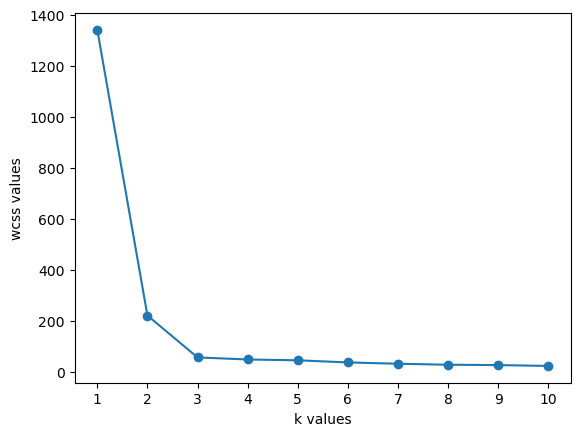

In [75]:
# plot elbow curve-:
plt.plot(range(1,11),wcss,marker="o")
plt.xticks(range(1,11))
plt.xlabel("k values")
plt.ylabel("wcss values")
plt.show()

# From this elbow-method-: most optimal k-value = 3 as from this point all wcss values are reducing minimal / VERY-LESS.

So k = 3 finalized

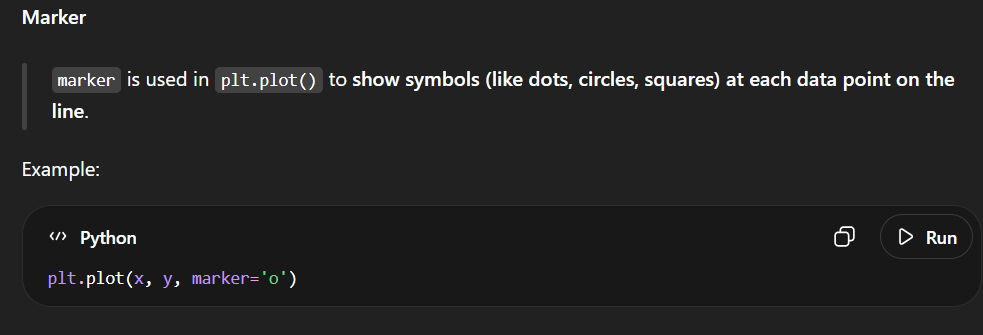
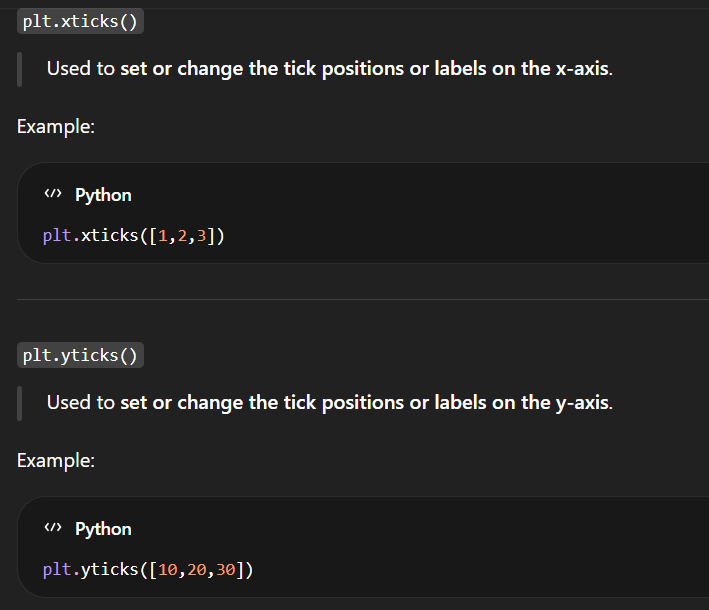
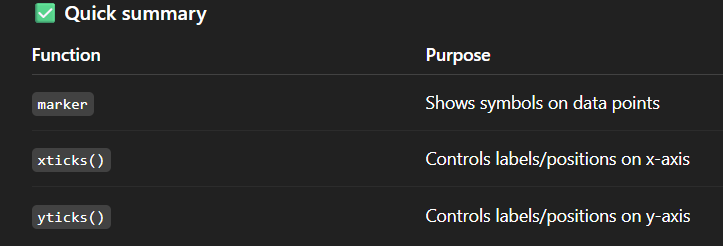

In [76]:
kmeans = KMeans(n_clusters=3,init='k-means++')

In [77]:
kmeans.fit_predict(X_train_scaled)

array([0, 2, 2, 1, 0, 2, 0, 1, 0, 0, 0, 1, 1, 1, 0, 2, 1, 1, 0, 1, 2, 0,
       2, 0, 2, 1, 2, 2, 2, 0, 2, 1, 2, 2, 2, 2, 1, 1, 0, 1, 0, 1, 2, 2,
       1, 0, 0, 1, 2, 2, 1, 1, 1, 0, 1, 2, 2, 2, 1, 1, 2, 1, 2, 1, 0, 0,
       1, 0, 2, 0, 0, 2, 1, 2, 2, 1, 2, 1, 1, 0, 0, 0, 2, 0, 1, 1, 0, 2,
       0, 1, 0, 1, 2, 1, 2, 1, 0, 2, 0, 0, 0, 2, 1, 2, 1, 1, 1, 1, 0, 1,
       2, 0, 1, 1, 1, 0, 1, 0, 0, 0, 2, 2, 1, 2, 0, 2, 1, 1, 2, 2, 0, 2,
       0, 2, 1, 2, 2, 0, 2, 1, 0, 0, 1, 1, 1, 0, 0, 2, 1, 2, 0, 2, 2, 1,
       1, 0, 2, 2, 1, 2, 2, 0, 2, 1, 2, 1, 2, 2, 1, 0, 1, 1, 1, 0, 2, 1,
       0, 1, 2, 1, 2, 2, 2, 2, 2, 0, 0, 2, 1, 2, 2, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 2, 1, 0, 0, 0, 1, 1, 0, 1, 0, 2, 0, 0, 2, 0, 1, 2, 1,
       2, 0, 1, 1, 1, 2, 2, 2, 1, 0, 1, 0, 1, 2, 1, 1, 0, 2, 2, 0, 1, 0,
       0, 2, 2, 1, 2, 0, 1, 2, 1, 0, 0, 1, 1, 2, 2, 0, 1, 0, 2, 2, 0, 0,
       2, 1, 0, 0, 2, 0, 0, 2, 2, 2, 0, 1, 1, 0, 2, 0, 0, 1, 0, 0, 0, 0,
       2, 0, 0, 2, 0, 2, 0, 2, 1, 1, 1, 0, 0, 0, 0,

All datapoints who have got "0" label are part of cluster-1

All datapoints who have got "1" label are part of cluster-2

All datapoints who have got "2" label are part of cluster-3

In [78]:
y_pred = kmeans.predict(X_test_scaled)

In [79]:
y_pred

array([0, 1, 1, 0, 2, 2, 1, 1, 2, 2, 2, 0, 0, 0, 0, 1, 0, 2, 1, 2, 1, 0,
       2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 1, 0, 0, 1, 0, 0, 2, 2, 0, 2, 2, 1,
       1, 1, 2, 1, 1, 2, 2, 2, 1, 1, 1, 2, 0, 1, 0, 2, 1, 2, 0, 2, 1, 0,
       1, 0, 0, 2, 2, 0, 0, 1, 1, 1, 0, 1, 0, 2, 1, 1, 0, 0, 1, 0, 0, 2,
       1, 2, 1, 0, 0, 1, 2, 1, 0, 0, 2, 1, 1, 2, 2, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 2, 0, 2, 1, 1, 0, 1, 2, 0, 0, 2, 1, 1,
       2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 0, 2, 1, 0, 2, 0, 1, 2, 1, 0, 0, 0,
       2, 0, 2, 0, 1, 2, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 2, 2, 1, 0, 0, 2,
       1, 2, 0, 0, 0, 1, 0, 2, 2, 2, 1, 2, 1, 0, 0, 0, 2, 2, 0, 0, 1, 1,
       1, 2, 0, 2, 0, 1, 2, 2, 0, 0, 2, 2, 0, 1, 1, 1, 1, 1, 2, 2, 0, 1,
       1, 0, 2, 1, 1, 2, 1, 2, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 0, 2, 2, 1,
       1, 0, 1, 0, 2, 0, 0, 1, 0, 1, 1, 1, 2, 1, 1, 2, 0, 0, 1, 1, 1, 0,
       2, 0, 0, 0, 0, 1, 0, 2, 1, 1, 1, 2, 2, 1, 0, 1, 1, 0, 0, 2, 2, 2,
       0, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 1, 2, 2, 2,

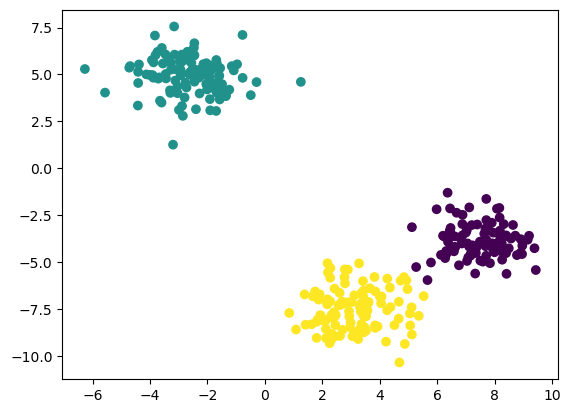

In [80]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

So; here we got good clustering on test data by finding optimal k-value via ELBOW-METHOD for k-means clustering

But; sometimes this validation of k-value via elbow-method is tough as not always we will get a point after which there will be very less changes in wcss value and elbow method also consumes lot of computation power as we need to apply k-means algo again and again for different-different k-values.

Also; sometimes by looking at graph of ELBOW METHOD it will be tough to select which k-value is the most optimal one .i.e the point of k-value after which there will be very less changes in wcss from that point -: It will be tough to select as at all k-value points there can be abrupt/rapid decrease in wcss values. 

So there are more 2 different ways for validation of k-value apart from elbow method-: 
# 1) kneelocator
# 2) Silhoutee scoring

In [86]:
# library for knee locator
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [82]:
from kneed import KneeLocator

# knee_locator method is used for detecting the knee of the elbow-method graph that is the most optimal k-value after which the wcss starts decreasing in small amount.

So; knee_locator will find most optimal value of "k" from the elbow method graph according to the PARAMETERS passed to this method

Widely used parameters of knee_locator is as follows-:
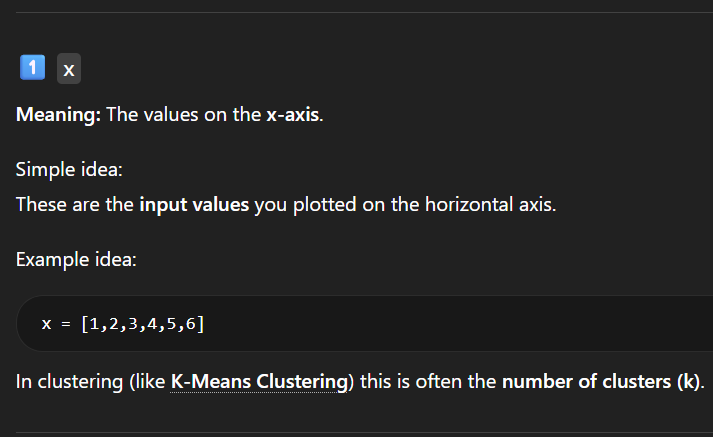
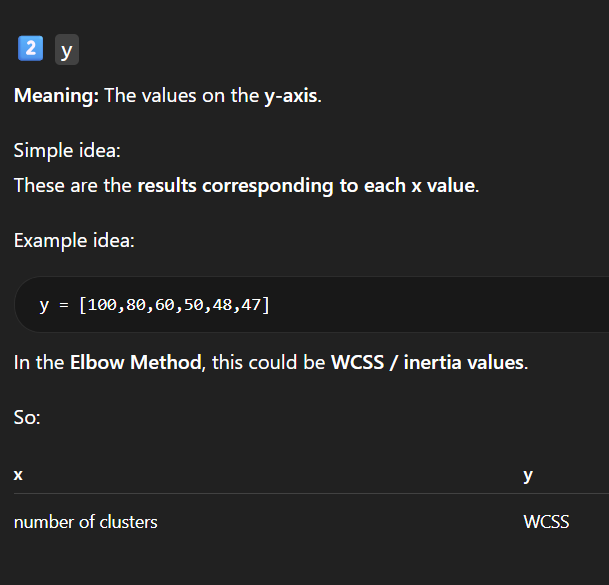
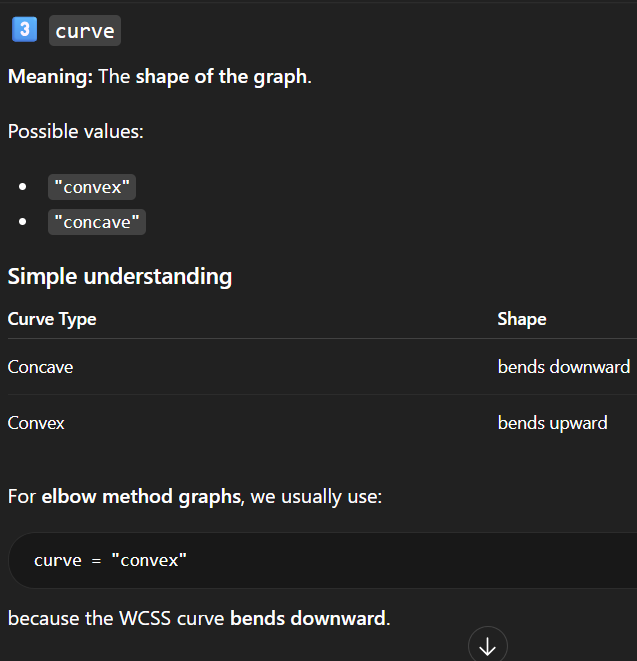
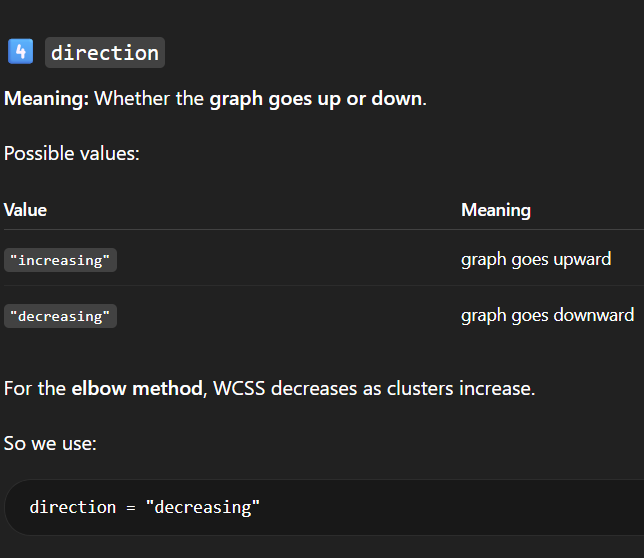
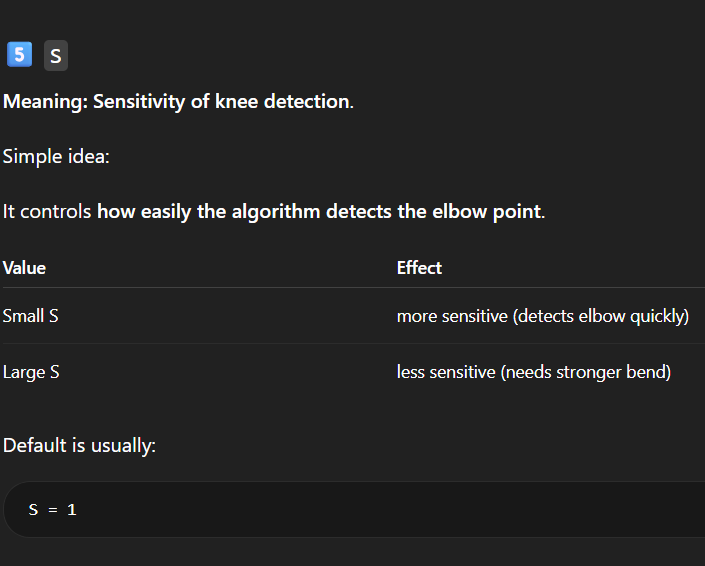
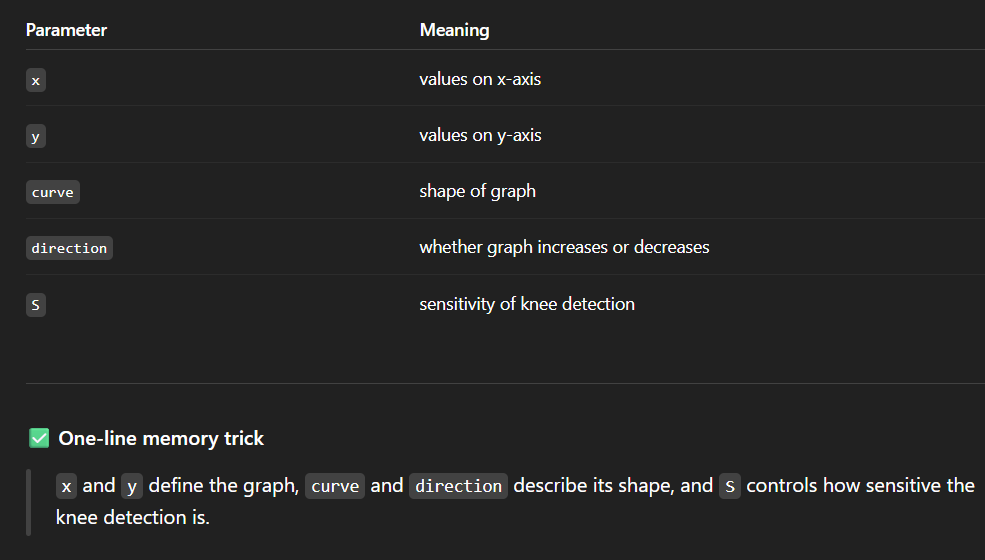


In [83]:
wcss

[1340.0000000000005,
 221.28730926600167,
 57.0809414010877,
 49.05484595297624,
 45.78766034070366,
 37.548438288512074,
 32.28828312474768,
 28.48077130779489,
 27.02917566099134,
 23.796358724793702]

In [84]:
kl = KneeLocator(x=range(1,11),y=wcss,curve="convex",direction="decreasing")

An elbow method curve is a covex graph with a decreasing direction

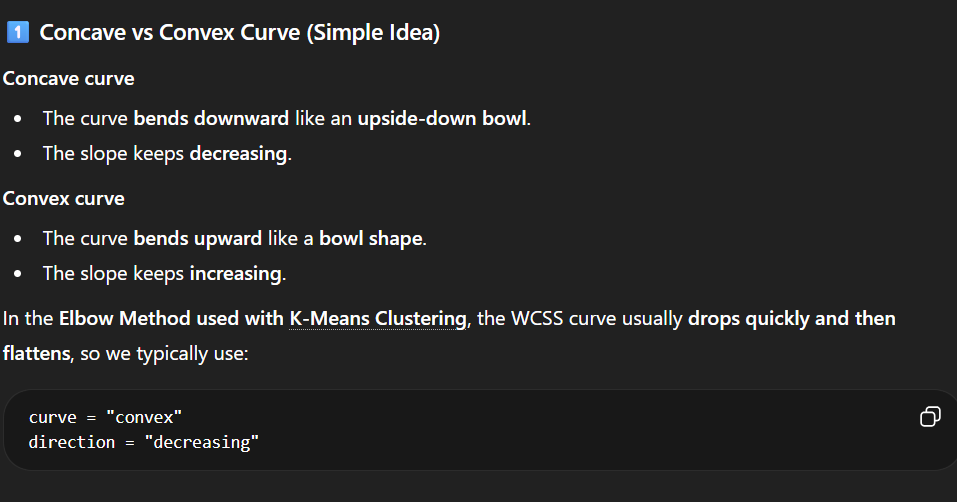
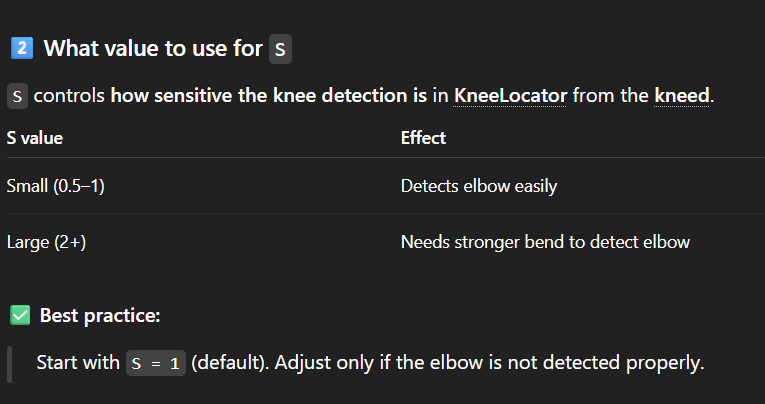
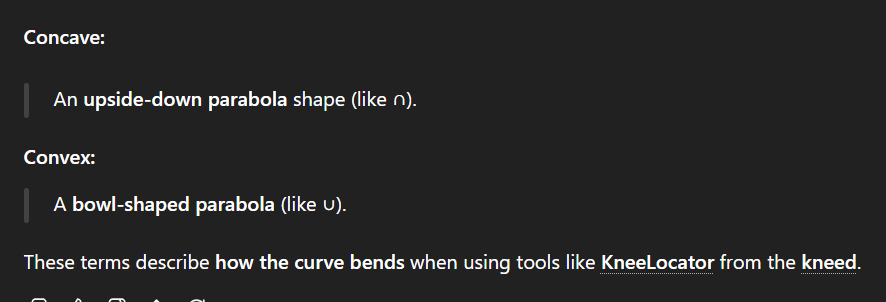

In "elbow" attribute of KneeLocator instance the elbow-point of elbow method graph .i.e. the most optimal "k" value from which the "wcss" decreases in a very less amount will be stored.

In [85]:
kl.elbow

np.int64(3)

So; from knee-locator -: the knee location .i.e. most optimal k-value for k-means clustering = 3 for this dataset.

2) Sihouetee Scoring

In [87]:
from sklearn.metrics import silhouette_score

In [88]:
silhouette_coefficinets=[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficinets.append(score)

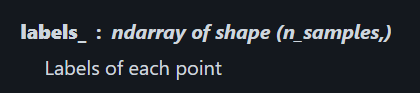

"labels_" attribute of KMeans instance stores the labels .i.e cluster-labels  which tells to which cluster-: each record/row of the given dataset is assigned

In [ ]:
# "labels_" attribute value where k = 10
# So; total clusters are 10. First cluster label = 0 ;  Last cluster label  = 9
kmeans.labels_

array([2, 7, 0, 9, 6, 4, 5, 9, 2, 5, 5, 8, 1, 1, 6, 0, 3, 8, 6, 8, 0, 5,
       7, 2, 4, 1, 7, 0, 7, 5, 0, 1, 0, 7, 4, 0, 9, 3, 2, 8, 5, 1, 0, 7,
       3, 2, 6, 9, 7, 4, 1, 8, 3, 5, 8, 4, 7, 7, 9, 1, 7, 1, 0, 1, 6, 5,
       8, 2, 0, 6, 5, 7, 1, 4, 4, 9, 0, 3, 9, 6, 6, 6, 0, 2, 8, 9, 2, 0,
       2, 1, 6, 9, 0, 9, 0, 8, 2, 0, 5, 5, 6, 0, 1, 7, 1, 1, 9, 3, 5, 9,
       4, 5, 3, 1, 3, 6, 1, 5, 6, 2, 4, 4, 1, 7, 5, 4, 8, 1, 0, 0, 5, 0,
       2, 7, 9, 4, 0, 6, 0, 8, 2, 2, 1, 1, 9, 2, 2, 4, 3, 4, 5, 4, 4, 1,
       9, 6, 0, 7, 1, 0, 4, 6, 0, 1, 0, 8, 0, 0, 3, 6, 9, 1, 8, 5, 4, 8,
       5, 8, 0, 9, 7, 7, 0, 7, 0, 5, 2, 4, 8, 7, 4, 6, 6, 5, 9, 3, 9, 8,
       6, 3, 5, 9, 7, 1, 2, 2, 5, 3, 1, 2, 8, 2, 7, 2, 6, 4, 6, 9, 4, 8,
       0, 6, 8, 9, 8, 4, 7, 4, 9, 2, 8, 6, 9, 0, 8, 3, 5, 4, 7, 5, 3, 5,
       2, 7, 7, 8, 0, 5, 9, 4, 9, 5, 6, 8, 1, 7, 4, 2, 9, 2, 0, 0, 2, 2,
       4, 1, 2, 5, 4, 6, 5, 7, 0, 7, 2, 1, 1, 2, 0, 6, 5, 8, 6, 5, 5, 5,
       4, 6, 6, 7, 6, 0, 6, 4, 8, 8, 1, 6, 2, 6, 5,

In [89]:
silhouette_coefficinets

[np.float64(0.7649258783302013),
 np.float64(0.7526499378740994),
 np.float64(0.5802898106145936),
 np.float64(0.5172772495057949),
 np.float64(0.3447793447734381),
 np.float64(0.3355193676555099),
 np.float64(0.3432298070506171),
 np.float64(0.34994986891305424),
 np.float64(0.3298581913712552)]

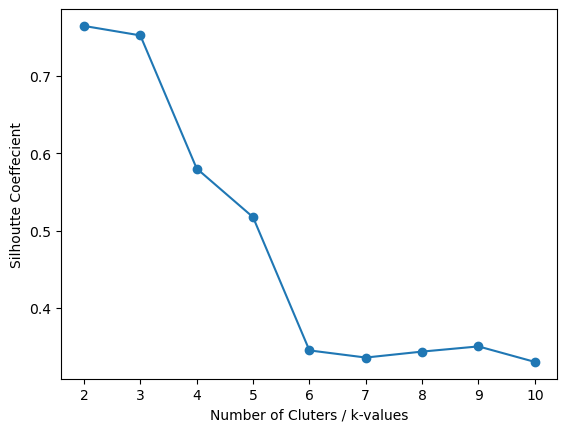

In [93]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficinets,marker="o")
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters / k-values")
plt.ylabel("Silhoutte Coeffecient")
plt.show()

Since here k=2 and k=3 have HIGHEST and almost SAME Silhoutte score with very little difference in their Silhouette score.

So which one to k-value to select will be decide by these rules-:

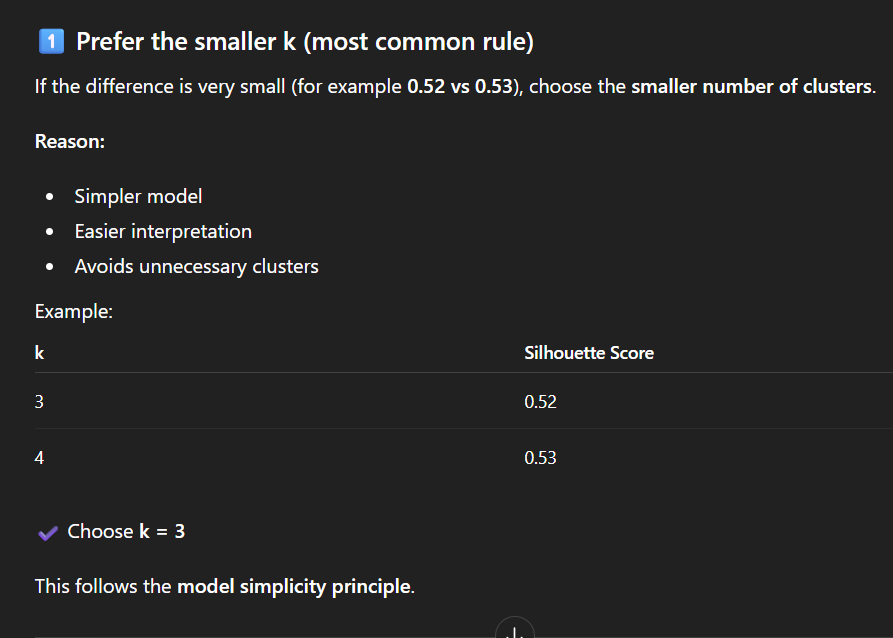
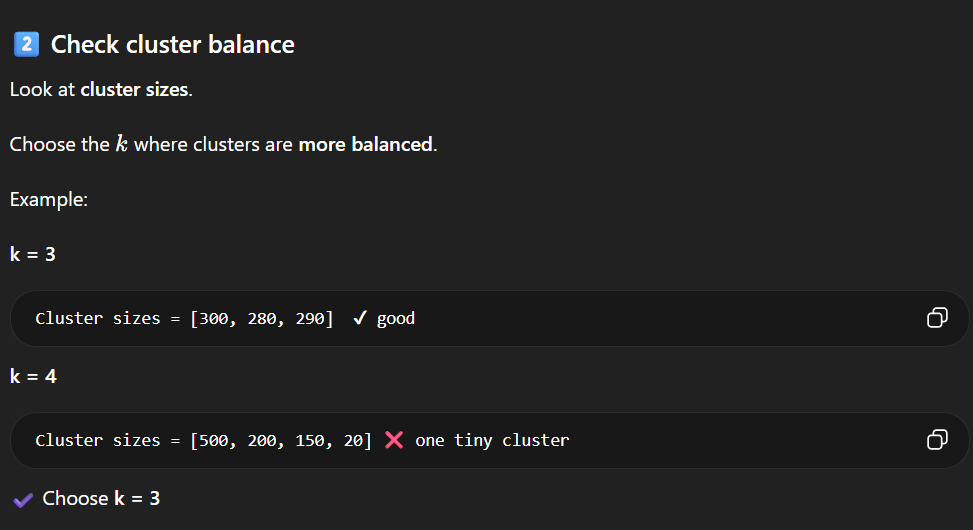
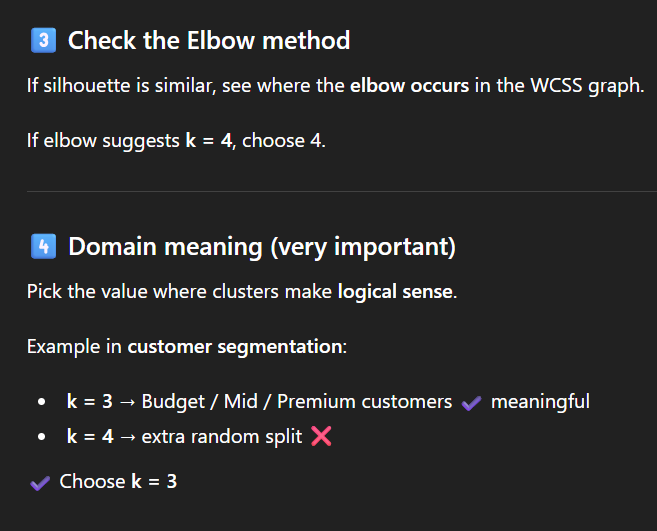

SUMMARY:

If two k values have almost the same silhouette score, the smaller 
k is usually preferred because it gives a simpler and more interpretable clustering. However, if the Elbow method clearly suggests a higher 
k, then that k can be selected. Also check cluster balance—choose the 
k where cluster sizes are more balanced and avoid cases where one cluster is extremely small. Finally, consider domain meaning and select the 
k where clusters make logical sense (for example, customer groups like Budget, Mid, and Premium).

# So; our elbow method graph and also Knee-locator method suggests k=3 
# So; we will NOT use k=2  and use k = 3

# Always select that k-value in K-Means Clustering which gives HIGHEST SILHOUETTE SCORE as compared to all the other k-values.